##**Informe de Análisis de Evasion de Clientes (CHURN)**

####**Introducción**

####El presente análisis tiene como objetivo comprender el fenómeno de evasión de clientes (Churn) en la empresa TelecomX. La evasión de clientes ocurre cuando un usuario decide cancelar o abandonar el servicio contratado, lo que representa un problema importante para las empresas de telecomunicaciones, ya que implica pérdida de ingresos y aumento en los costos de adquisición de nuevos clientes.

A través del análisis de datos, es posible identificar patrones en el comportamiento de los clientes que abandonan el servicio. Esto permite comprender qué factores influyen en la cancelación y, con base en ello, diseñar estrategias que ayuden a mejorar la retención de clientes.

Para este análisis se utilizaron técnicas de limpieza, transformación y exploración de datos con el fin de obtener información relevante que permita comprender mejor las características de los clientes y su relación con la evasión.

####**Limpieza y Tratamiento de Datos**

####En la fase inicial se realizó la importación de los datos desde un archivo JSON alojado en GitHub. Posteriormente, se aplicaron diferentes procesos de preparación de los datos para garantizar su calidad y consistencia antes de realizar el análisis.

Primero se normalizó la estructura del archivo JSON para convertirlo en un DataFrame de Pandas que facilitara su manipulación. Luego se revisaron posibles problemas en los datos, como valores nulos, duplicados e inconsistencias en los tipos de datos.

Durante esta etapa también se realizaron algunas transformaciones importantes:

- Se convirtió la columna Total Charges a formato numérico, ya que algunos registros presentaban inconsistencias.

- Se eliminaron registros con valores faltantes en variables clave.

- Se transformaron variables categóricas como Partner, Dependents y Churn a formato binario (1 y 0) para facilitar su análisis.

- Se renombraron algunas columnas para mejorar la claridad del dataset.

- Se creó una nueva variable llamada Cuentas_Diarias, calculada a partir de los cargos mensuales divididos entre 30 días, lo que permitió obtener una perspectiva más detallada del comportamiento del gasto de los clientes.

Estos pasos permitieron contar con un conjunto de datos limpio, consistente y preparado para el análisis exploratorio.

###**Análisis Exploratorio de Datos**

####Una vez preparados los datos, se realizó un análisis descriptivo para comprender mejor las características generales del conjunto de datos. Se calcularon métricas estadísticas como media, mediana, desviación estándar y valores mínimos y máximos para variables numéricas como:

Antigüedad del cliente

Cargos mensuales

Cargos totales

Cuentas diarias

Los resultados muestran que la antigüedad promedio de los clientes es aproximadamente de 32 meses, mientras que el cargo mensual promedio se encuentra alrededor de 64.8 unidades monetarias.

Posteriormente se analizó la distribución de la variable Churn, observando que la mayoría de los clientes permanecen en la empresa, mientras que una proporción menor corresponde a clientes que cancelaron el servicio.

También se realizaron visualizaciones para analizar cómo se comporta la evasión en función de diferentes variables categóricas como:

- Tipo de contrato

- Método de pago

- Servicios contratados

- Características del cliente

Este análisis permitió identificar patrones en los perfiles de clientes con mayor probabilidad de cancelación.

Además, se exploró la relación entre variables numéricas y la evasión, analizando cómo factores como el gasto total o la antigüedad del cliente pueden influir en la probabilidad de cancelar el servicio.

###**Conclusiones e Insights**

####A partir del análisis realizado se pueden identificar varios hallazgos importantes sobre el comportamiento de los clientes.

En primer lugar, se observa que existe una proporción significativa de clientes que cancelan el servicio, lo que indica que la evasión representa un desafío importante para la empresa.

También se evidenció que variables como la antigüedad del cliente y los cargos mensuales pueden influir en el comportamiento de cancelación. En muchos casos, los clientes con menor tiempo en la empresa presentan una mayor tendencia a abandonar el servicio.

Asimismo, algunos tipos de contrato y características del servicio pueden estar asociados con mayores tasas de evasión, lo que sugiere la necesidad de revisar las estrategias de fidelización y satisfacción del cliente.

El análisis exploratorio permitió comprender mejor el perfil de los clientes y detectar posibles factores que influyen en la cancelación del servicio.

###**Recomendaciones**

####Con base en los resultados obtenidos, se pueden plantear algunas recomendaciones estratégicas para reducir la evasión de clientes:

- Implementar estrategias de fidelización dirigidas especialmente a clientes con baja antigüedad en la empresa.

- Analizar los planes de servicio y contratos que presentan mayor tasa de cancelación para identificar oportunidades de mejora.

- Desarrollar programas de retención que incluyan beneficios o incentivos para clientes en riesgo de abandono.

- Utilizar modelos predictivos de churn que permitan anticipar qué clientes tienen mayor probabilidad de cancelar el servicio.

- Fortalecer las estrategias de atención y experiencia del cliente para mejorar la satisfacción general.

Estas acciones pueden contribuir a mejorar la retención de clientes, optimizar los ingresos de la empresa y fortalecer la relación con los usuarios.

In [ ]:
import requests
import pandas as pd

raw_json_url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(raw_json_url)
data = response.json()

df = pd.json_normalize(data)

print("Dimensión inicial:", df.shape)

Dimensión inicial: (7267, 21)


In [ ]:
print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados totales:")
print(df.duplicated().sum())

print("\nDuplicados en customerID:")
print(df['customerID'].duplicated().sum())

print("\nTipos de datos:")
print(df.dtypes)


Valores nulos por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Registros duplicados totales:
0

Duplicados en customerID:
0

Tipos de datos:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
custome

In [ ]:
df['account.Charges.Total'] = pd.to_numeric(
    df['account.Charges.Total'],
    errors='coerce'
)

print("\nNulos después de conversión:")
print(df['account.Charges.Total'].isnull().sum())


Nulos después de conversión:
11


In [ ]:
df = df.dropna(subset=['Churn', 'account.Charges.Total'])

print("Dimensión después de limpieza:", df.shape)

Dimensión después de limpieza: (7256, 21)


In [ ]:
print("\nValores únicos en Churn:")
print(df['Churn'].unique())

print("\nValores únicos en Partner:")
print(df['customer.Partner'].unique())

print("\nValores únicos en Dependents:")
print(df['customer.Dependents'].unique())


Valores únicos en Churn:
['No' 'Yes' '']

Valores únicos en Partner:
['Yes' 'No']

Valores únicos en Dependents:
['Yes' 'No']


In [ ]:
df['Churn'] = df['Churn'].str.strip()
df['customer.Partner'] = df['customer.Partner'].str.strip()
df['customer.Dependents'] = df['customer.Dependents'].str.strip()

# Mapear correctamente
binary_cols = ['customer.Partner', 'customer.Dependents', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print("\nResumen después del mapeo:")
print(df[binary_cols].describe())


Resumen después del mapeo:
       customer.Partner  customer.Dependents        Churn
count       7256.000000          7256.000000  7032.000000
mean           0.483600             0.299063     0.265785
std            0.499765             0.457879     0.441782
min            0.000000             0.000000     0.000000
25%            0.000000             0.000000     0.000000
50%            0.000000             0.000000     0.000000
75%            1.000000             1.000000     1.000000
max            1.000000             1.000000     1.000000


In [ ]:
df = df.rename(columns={
    'account.Charges.Monthly': 'Cargos_Mensuales',
    'account.Charges.Total': 'Cargos_Totales',
    'customer.tenure': 'Antiguedad'
})

In [ ]:
df['Cuentas_Diarias'] = df['Cargos_Mensuales'] / 30

print(df[['Cargos_Mensuales', 'Cuentas_Diarias']].head())

print("\nResumen estadístico de Cuentas_Diarias:")
print(df['Cuentas_Diarias'].describe())

   Cargos_Mensuales  Cuentas_Diarias
0              65.6         2.186667
1              59.9         1.996667
2              73.9         2.463333
3              98.0         3.266667
4              83.9         2.796667

Resumen estadístico de Cuentas_Diarias:
count    7256.000000
mean        2.158514
std         1.004191
min         0.608333
25%         1.181667
50%         2.343333
75%         2.996667
max         3.958333
Name: Cuentas_Diarias, dtype: float64


In [ ]:
df = df.dropna(subset=['Churn'])
print(df.describe().T)

                         count         mean          std        min  \
Churn                   7032.0     0.265785     0.441782   0.000000   
customer.SeniorCitizen  7032.0     0.162400     0.368844   0.000000   
customer.Partner        7032.0     0.482509     0.499729   0.000000   
customer.Dependents     7032.0     0.298493     0.457629   0.000000   
Antiguedad              7032.0    32.421786    24.545260   1.000000   
Cargos_Mensuales        7032.0    64.798208    30.085974  18.250000   
Cargos_Totales          7032.0  2283.300441  2266.771362  18.800000   
Cuentas_Diarias         7032.0     2.159940     1.002866   0.608333   

                              25%       50%          75%          max  
Churn                     0.00000     0.000     1.000000     1.000000  
customer.SeniorCitizen    0.00000     0.000     0.000000     1.000000  
customer.Partner          0.00000     0.000     1.000000     1.000000  
customer.Dependents       0.00000     0.000     1.000000     1.000000  


In [ ]:
print("\nAnálisis descriptivo general:")
print(df.describe().T)


Análisis descriptivo general:
                         count         mean          std        min  \
Churn                   7032.0     0.265785     0.441782   0.000000   
customer.SeniorCitizen  7032.0     0.162400     0.368844   0.000000   
customer.Partner        7032.0     0.482509     0.499729   0.000000   
customer.Dependents     7032.0     0.298493     0.457629   0.000000   
Antiguedad              7032.0    32.421786    24.545260   1.000000   
Cargos_Mensuales        7032.0    64.798208    30.085974  18.250000   
Cargos_Totales          7032.0  2283.300441  2266.771362  18.800000   
Cuentas_Diarias         7032.0     2.159940     1.002866   0.608333   

                              25%       50%          75%          max  
Churn                     0.00000     0.000     1.000000     1.000000  
customer.SeniorCitizen    0.00000     0.000     0.000000     1.000000  
customer.Partner          0.00000     0.000     1.000000     1.000000  
customer.Dependents       0.00000     0.0

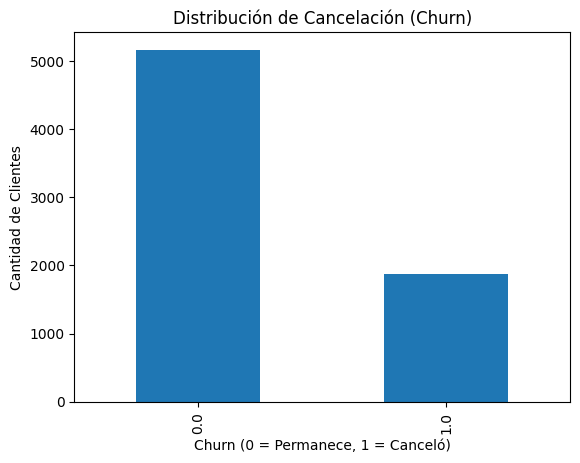

In [ ]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure()
churn_counts.plot(kind='bar')

plt.title("Distribución de Cancelación (Churn)")
plt.xlabel("Churn (0 = Permanece, 1 = Canceló)")
plt.ylabel("Cantidad de Clientes")

plt.show()

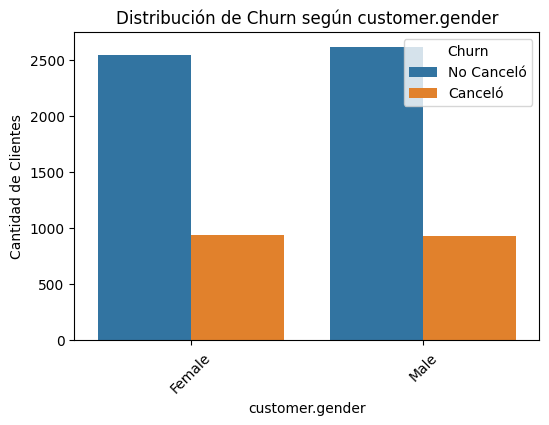

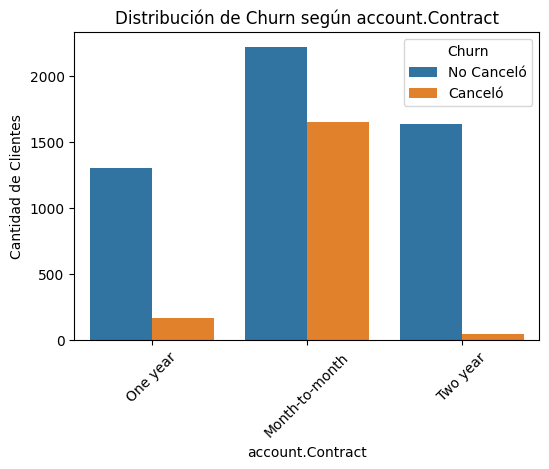

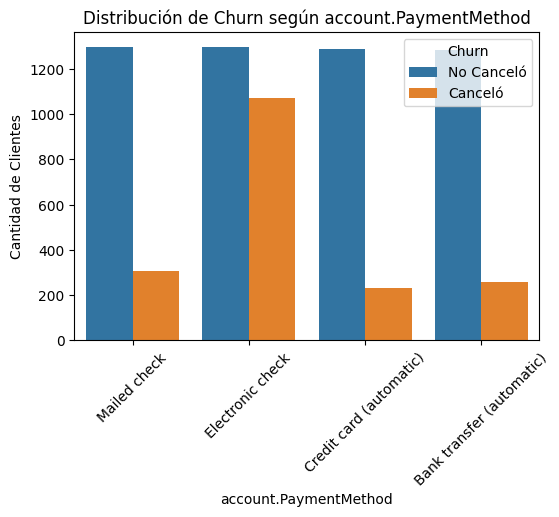

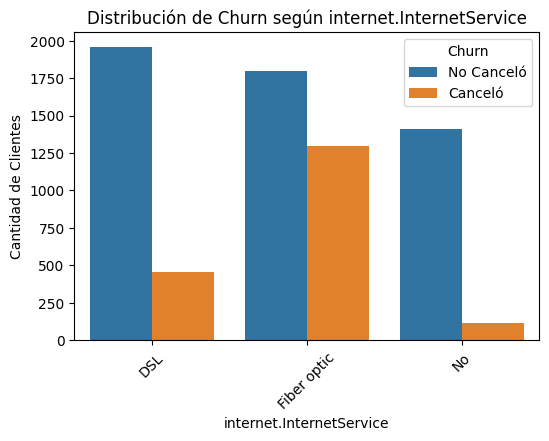

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['customer.gender', 'account.Contract', 'account.PaymentMethod', 'internet.InternetService']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f"Distribución de Churn según {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de Clientes")
    plt.legend(title='Churn', labels=['No Canceló', 'Canceló'])
    plt.xticks(rotation=45)

    plt.show()

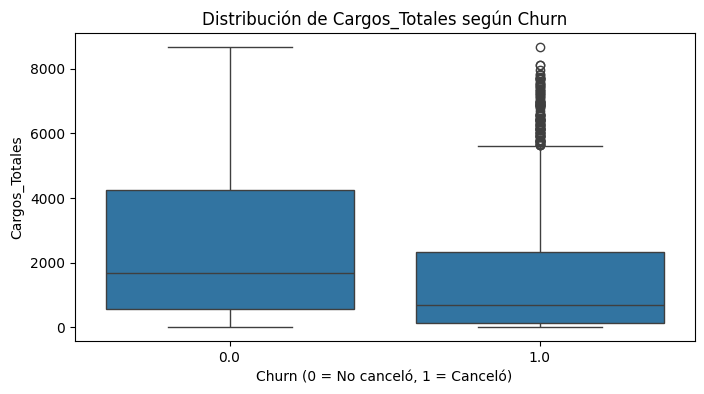

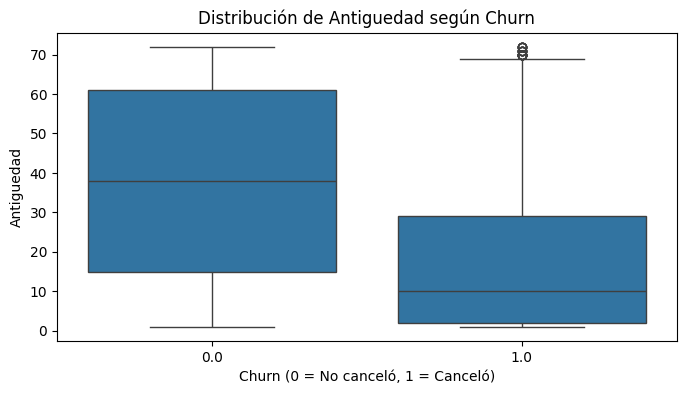

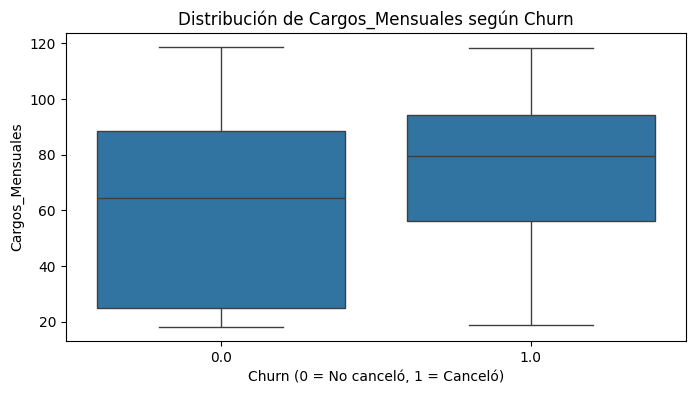

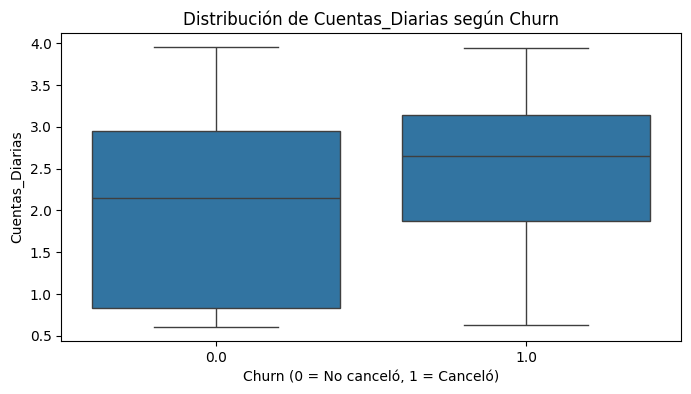

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Cargos_Totales', 'Antiguedad', 'Cargos_Mensuales', 'Cuentas_Diarias']

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f"Distribución de {col} según Churn")
    plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
    plt.ylabel(col)
    plt.show()